In [82]:
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
import torch

from vsa_ogm.data import load_data
from vsa_ogm.mappers.sa.sa_vsa_mapper import SA_VSA_OGM

In [83]:
agent1_paths = {
    "config": "/home/ssnyde9/dev/VSA-OGM/logs/exp3_sa_toymap_vsa_ogm_cuda_general_agent1/config.yaml",
    "empty_memories": "/home/ssnyde9/dev/VSA-OGM/logs/exp3_sa_toymap_vsa_ogm_cuda_general_agent1/epochs/epoch_366/empty_tile_memories.npy",
    "occupied_memories": "/home/ssnyde9/dev/VSA-OGM/logs/exp3_sa_toymap_vsa_ogm_cuda_general_agent1/epochs/epoch_366/occupied_tile_memories.npy"
}
agent2_paths = {
    "config": "/home/ssnyde9/dev/VSA-OGM/logs/exp3_sa_toymap_vsa_ogm_cuda_general_agent2/config.yaml",
    "empty_memories": "/home/ssnyde9/dev/VSA-OGM/logs/exp3_sa_toymap_vsa_ogm_cuda_general_agent2/epochs/epoch_366/empty_tile_memories.npy",
    "occupied_memories": "/home/ssnyde9/dev/VSA-OGM/logs/exp3_sa_toymap_vsa_ogm_cuda_general_agent2/epochs/epoch_366/occupied_tile_memories.npy"
}

In [84]:
agent1_memories = {
    "empty": np.load(agent1_paths["empty_memories"]),
    "occupied": np.load(agent1_paths["occupied_memories"])
}
agent2_memories = {
    "empty": np.load(agent2_paths["empty_memories"]),
    "occupied": np.load(agent2_paths["occupied_memories"])
}
agent1_config = OmegaConf.load(open(agent1_paths["config"]))
agent2_config = OmegaConf.load(open(agent2_paths["config"]))

In [85]:
agent1_dataset = load_data(agent1_config, None)
agent2_dataset = load_data(agent2_config, None)

Found 0 files in datasets/ma/toysim_agent1 with prefix results_frame_ and suffix .npz
Found 0 files in datasets/ma/toysim_agent2 with prefix results_frame_ and suffix .npz


In [86]:
global_mapper = SA_VSA_OGM(agent1_config, None)

Building quadrant level [0]...
World Bounds Norm:  [100, 100]
World Bounds Norm Quadrant X:  50.0
World Bounds Norm Quadrant X:  50.0
World Bounds Norm Quadrant X:  50.0
World Bounds Norm Quadrant X:  50.0
Num Quadrants =  100.0
Num Quadrants =  100.0
New Bounds Norm:  [np.float64(100.0), np.float64(100.0)]
New Bounds Norm Quadrant X:  50.0
New Bounds Norm Quadrant X:  50.0
New Bounds Norm Quadrant X:  50.0
New Bounds Norm Quadrant X:  50.0
Quadrant Level [0] - Number of Quadrants: 4
Quadrant Level [0] - Quadrant Size (Bins): 50, 50
Quadrant Level [0] - Quadrant Size (Meters): 50.0, 50.0
Quadrant Level [0] - Level Size (Bins): 100, 100
Quadrant Level [0] - Level Size (Meters): 100.0, 100.0
Building quadrant indices...
Finished building quadrant indices.
Building XY axis linspace...
Finished building XY axis linspace.
Building XY axis vectors...
Finished building XY axis vectors.
Loading axis vectors from file
Building XY axis matrix...
torch.Size([50, 32000])
torch.Size([50, 32000])
to

/home/ssnyde9/dev/VSA-OGM/vsa_ogm/mappers/sa/sa_vsa_mapper.py:247: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.xy_axis_vectors = torch.load(vector_path)


In [87]:
print(f"Agent 1 Empty Memory Shape: {agent1_memories['empty'].shape}")
print(f"Agent 1 Occupied Memory Shape: {agent1_memories['occupied'].shape}")
print(f"Agent 2 Empty Memory Shape: {agent2_memories['empty'].shape}")
print(f"Agent 2 Occupied Memory Shape: {agent2_memories['occupied'].shape}")

Agent 1 Empty Memory Shape: (4, 32000)
Agent 1 Occupied Memory Shape: (4, 32000)
Agent 2 Empty Memory Shape: (4, 32000)
Agent 2 Occupied Memory Shape: (4, 32000)


In [88]:
fusion_occupied_memories = np.sum([
    agent1_memories["occupied"],
    agent2_memories["occupied"]
], axis=0)
fusion_empty_memories = np.sum([
    agent1_memories["empty"],
    agent2_memories["empty"]
], axis=0)

In [89]:
global_mapper.occupied_quadrant_memory_vectors = torch.from_numpy(fusion_occupied_memories).to(agent1_config.mapping.device)
global_mapper.empty_quadrant_memory_vectors = torch.from_numpy(fusion_empty_memories).to(agent1_config.mapping.device)

In [90]:
from vsa_ogm.mappers.sa.sa_vsa_mapper import compute_mm

In [91]:
start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)
start_event.record()

occ_norm = global_mapper.occupied_quadrant_memory_vectors / torch.norm(
    global_mapper.occupied_quadrant_memory_vectors, dim=1, keepdim=True
)
empty_norm = global_mapper.empty_quadrant_memory_vectors / torch.norm(
    global_mapper.empty_quadrant_memory_vectors, dim=1, keepdim=True
)

# compute dot product of the memory vectors across the quadrant matrices
occupied_results = compute_mm(occ_norm, global_mapper.xy_axis_matrix)
empty_results = compute_mm(empty_norm, global_mapper.xy_axis_matrix)

# convert the results matrices into a flat 2d matrix
occupied_results = occupied_results.view(
    global_mapper.num_tiles,
    global_mapper.num_tiles,
    global_mapper.quadrant_indices_y[1],
    global_mapper.quadrant_indices_x[1]
)
occupied_results = occupied_results.permute(1, 2, 0, 3)
occupied_results = occupied_results.reshape(
    global_mapper.num_tiles * global_mapper.quadrant_indices_y[1],
    global_mapper.num_tiles * global_mapper.quadrant_indices_x[1]
)
empty_results = empty_results.view(
    global_mapper.num_tiles,
    global_mapper.num_tiles,
    global_mapper.quadrant_indices_y[1],
    global_mapper.quadrant_indices_x[1]
)
empty_results = empty_results.permute(1, 2, 0, 3)
empty_results = empty_results.reshape(
    global_mapper.num_tiles * global_mapper.quadrant_indices_y[1],
    global_mapper.num_tiles * global_mapper.quadrant_indices_x[1]
)

global_mapper.xy_axis_occupied_heatmap = torch.nan_to_num(occupied_results)
global_mapper.xy_axis_empty_heatmap = torch.nan_to_num(empty_results)

occupied_heatmap, empty_heatmap, _, intermediate_maps = global_mapper.decode_heatmaps(
    global_mapper.xy_axis_occupied_heatmap,
    global_mapper.xy_axis_empty_heatmap
)

global_mapper.ogm = occupied_heatmap - empty_heatmap
global_mapper.ogm = global_mapper.ogm.cpu().numpy()

end_event.record()
torch.cuda.synchronize()
print(f"Elaspsed time: {start_event.elapsed_time(end_event)} ms")

1.7350080013275146
Elaspsed time: 6.174943923950195 ms


In [92]:
# load the datasets from each agent
from sklearn import metrics
from sklearn.model_selection import train_test_split
from vsa_ogm.data import load_data

agent1_config.data.data_dir = "/home/ssnyde9/dev/VSA-OGM/datasets/ma/toysim_agent1"
agent2_config.data.data_dir = "/home/ssnyde9/dev/VSA-OGM/datasets/ma/toysim_agent2"

agent1_dataset = load_data(agent1_config, None)
agent2_dataset = load_data(agent2_config, None)


global_trainX = []
global_trainy = []
global_testX = []
global_testy = []

for dataset in [agent1_dataset]:
    print(f"Dataset: {dataset}")
    print(f"Dataset Length: {len(dataset)}")
    for idx in range(len(dataset)):
        data = dataset[idx]

        data_batch: dict = dataset[idx]
        X: np.ndarray = data_batch["lidar_data"]
        y: np.ndarray = data_batch["occupancy"]

        # split the data into stratified training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=agent1_config.data.test_split,
            random_state=agent1_config.mapping_manager.seed,
            stratify=y
        )

        global_trainX.append(X_train)
        global_trainy.append(y_train)
        global_testX.append(X_test)
        global_testy.append(y_test)

global_trainX = np.vstack(global_trainX)
global_trainy = np.concatenate(global_trainy)
global_testX = np.vstack(global_testX)
global_testy = np.concatenate(global_testy)

Found 368 files in /home/ssnyde9/dev/VSA-OGM/datasets/ma/toysim_agent1 with prefix results_frame_ and suffix .npz
Found 368 files in /home/ssnyde9/dev/VSA-OGM/datasets/ma/toysim_agent2 with prefix results_frame_ and suffix .npz
Dataset: <vsa_ogm.data.sa.toysim_sa_dataset.ToySimSingleAgentDataset object at 0x78dbd370ea20>
Dataset Length: 367


In [93]:
# normalize the predictions based on the range of the OGM
ogm_min = np.min(global_mapper.ogm)
ogm_max = np.max(global_mapper.ogm)
train_pred = global_mapper.predict(global_trainX)[0]
test_pred = global_mapper.predict(global_testX)[0]
x_train_pred_norm = (train_pred - ogm_min) / (ogm_max - ogm_min)
x_test_pred_norm = (test_pred - ogm_min) / (ogm_max - ogm_min)
x_train_pred_norm = np.nan_to_num(x_train_pred_norm)
x_test_pred_norm = np.nan_to_num(x_test_pred_norm)

train_fpr, train_tpr, _ = metrics.roc_curve(global_trainy, x_train_pred_norm)
test_fpr, test_tpr, _ = metrics.roc_curve(global_testy, x_test_pred_norm)
train_auc = metrics.auc(train_fpr, train_tpr)
test_auc = metrics.auc(test_fpr, test_tpr)
print(f"Train AUC: {train_auc}")
print(f"Test AUC: {test_auc}")

train_nll = metrics.log_loss(global_trainy, x_train_pred_norm, labels=[0, 1])
test_nll = metrics.log_loss(global_testy, x_test_pred_norm, labels=[0, 1])
print(f"Train NLL: {train_nll}")
print(f"Test NLL: {test_nll}")

Train AUC: 0.9567831269139985
Test AUC: 0.9463435645696716
Train NLL: 0.30993264055757697
Test NLL: 0.32499739367385666


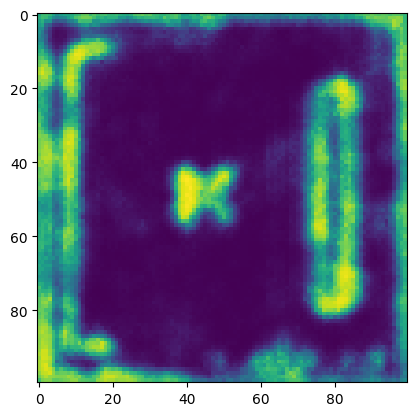

In [96]:
plt.imshow(intermediate_maps["occupied_entropy_prob"], cmap="viridis", interpolation="nearest")

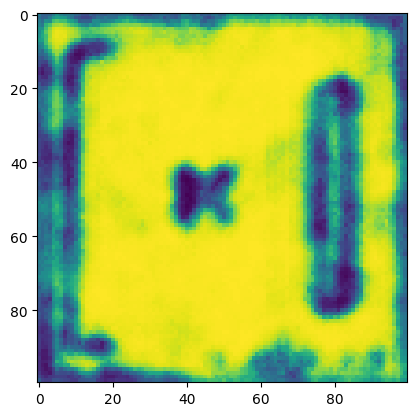

In [97]:
plt.imshow(intermediate_maps["empty_entropy_prob"], cmap="viridis", interpolation="nearest")

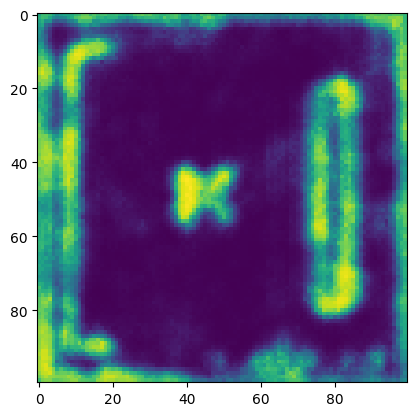

In [95]:
plt.imshow(global_mapper.ogm, cmap="viridis", interpolation="nearest")